# 5. Modelo Predictivo y Explicabilidad: XGBoost & SHAP

Como científicos de datos en salud pública, no solo nos interesa predecir, sino **entender**. Por eso, en este análisis entrenaremos un modelo **XGBoost (Extreme Gradient Boosting)** para estimar la tasa de mortalidad por cáncer gástrico a nivel departamental.

Para no quedarnos con una "caja negra" donde el modelo toma decisiones matemáticas que no entendemos, usaremos **SHAP (SHapley Additive exPlanations)**. Esta herramienta nos permite ver de forma exacta qué variables influyen en el riesgo y, lo más importante, si lo hacen para bien o para mal.

> **Control de Rigor Estadístico:** Para asegurar que el modelo sea realmente predictivo y no solo descriptivo, aplicamos **retrasos temporales ($Lags$)**. En lugar de usar los datos de vulnerabilidad de los fallecidos de 2024 para explicar las muertes de 2024, usamos la situación sanitaria de 2023. Esto elimina la "doble causalidad" (*Data Leakage*) y asegura que estamos midiendo cómo las carencias del pasado impactan en la mortalidad del presente.

In [27]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Inicializar JS para gráficos interactivos de SHAP
shap.initjs()

### 1. Construcción de Variables (Feature Engineering)

El éxito de este modelo no depende solo del algoritmo (XGBoost), sino de entregarle variables lógicas e informativas. En esta etapa, vamos a unir la información general de los departamentos (calidad del agua IRCA, tabaquismo y ruralidad) con características sociales extraídas de los pacientes.

**Control de Fuga de Datos (Lag $t-1$):**
Para no viciar el modelo (no podemos usar información de los difuntos de 2024 para estimar la tasa de mortalidad de 2024), extraeremos la proporción de fallecidos en el régimen subsidiado y sin asistencia médica, y la usaremos como una característica del **año siguiente**. En la práctica: evaluaremos cómo la vulnerabilidad sanitaria de un departamento en un año puntual impacta la tasa de mortalidad por cáncer al año siguiente.

In [28]:
# 1. Carga del panel consolidado
ruta_panel = "proyecto/data/analytical/panel_dpto_año.parquet"
df_panel = pd.read_parquet(ruta_panel)

# 2. FEATURE ENGINEERING INTELIGENTE & RIGUROSO (Data Leakage Fix: Lag t-1)
# Cargamos la base cruda (slim) que tiene variables demográficas por individuo
ruta_slim = "proyecto/data/analytical/mortalidad_raw_slim.parquet"
if pd.io.common.file_exists(ruta_slim):
    df_slim = pd.read_parquet(ruta_slim)
    
    # Aseguramos los tipos
    df_slim['Departamento_Residencia'] = pd.to_numeric(df_slim['Departamento_Residencia'], errors='coerce')
    df_slim['Anio_Defuncion'] = pd.to_numeric(df_slim['Anio_Defuncion'], errors='coerce')
    
    # DANE Dictionaries: 
    # Régimen 2 = Subsidiado, 5 = No Asegurado
    # Asistencia 2 = Sin Asistencia Médica
    
    df_slim['es_subsidiado_no_asegurado'] = np.where(df_slim['Regimen_Salud'].isin(['2', '5']), 1, 0)
    df_slim['sin_asistencia'] = np.where(df_slim['Asistencia_Medica'] == '2', 1, 0)
    
    # Agrupamos por Departamento y Año para calcular el % de estas vulnerabilidades
    df_vuln = df_slim.groupby(['Departamento_Residencia', 'Anio_Defuncion']).agg(
        prop_subsidiado_vulnerable_lag1=('es_subsidiado_no_asegurado', 'mean'),
        prop_sin_asistencia_lag1=('sin_asistencia', 'mean')
    ).reset_index().rename(columns={'Departamento_Residencia': 'cod_dpto', 'Anio_Defuncion': 'año'})
    
    # APLICANDO EL REZAGO ESPACIO-TEMPORAL (LAG t-1)
    # Sumamos 1 al año de la variable vulnerable. Así, la vulnerabilidad del 2015 
    # se usará para predecir la tasa de mortalidad del 2016. Esto elimina la endogeneidad.
    df_vuln['año'] = df_vuln['año'] + 1
    
    # Unimos con nuestro panel
    df_panel = df_panel.merge(df_vuln, on=['cod_dpto', 'año'], how='left')
    
    # Llenamos posibles nulos generados en la unión (ej. el primer año 2008 no tendrá lag de 2007)
    # Primero imputamos usando la media del mismo departamento
    df_panel['prop_subsidiado_vulnerable_lag1'] = df_panel.groupby('cod_dpto')['prop_subsidiado_vulnerable_lag1'].transform(lambda x: x.fillna(x.mean()))
    df_panel['prop_sin_asistencia_lag1'] = df_panel.groupby('cod_dpto')['prop_sin_asistencia_lag1'].transform(lambda x: x.fillna(x.mean()))
    
    # Si aún quedan nulos, imputamos con la media global
    df_panel['prop_subsidiado_vulnerable_lag1'] = df_panel['prop_subsidiado_vulnerable_lag1'].fillna(df_panel['prop_subsidiado_vulnerable_lag1'].mean())
    df_panel['prop_sin_asistencia_lag1'] = df_panel['prop_sin_asistencia_lag1'].fillna(df_panel['prop_sin_asistencia_lag1'].mean())

# 3. Variables a utilizar 
# Creamos la variable de proporción rural que ya estaba intrínseca
df_panel['prop_rural'] = df_panel['muertes_rural'] / (df_panel['muertes_total'] + 1e-9)

features = [
    'año', 
    'poblacion_total',
    'prop_rural',
    'irca_global',
    'prevalencia_tabaco',
    'prop_subsidiado_vulnerable_lag1',
    'prop_sin_asistencia_lag1'
]
target = 'tasa_ajustada_edad'

# Limpieza final para el modelo
df_model = df_panel[features + [target]].copy()

# Para variables como IRCA y Tabaco, si hay faltantes, imputamos temporalmente
df_model['irca_global'] = df_model['irca_global'].fillna(df_model['irca_global'].median())
df_model['prevalencia_tabaco'] = df_model['prevalencia_tabaco'].fillna(df_model['prevalencia_tabaco'].median())

# Asegurarnos de que no hay nulos en el target
df_model = df_model.dropna(subset=[target])

X = df_model[features]
y = df_model[target]

print(f"Dataset listo con {X.shape[0]} observaciones y {X.shape[1]} variables espacialmente rezagadas.")

Dataset listo con 561 observaciones y 7 variables espacialmente rezagadas.


### 2. Entrenamiento del Modelo XGBoost

Aquí configuramos y entrenamos nuestro modelo predictivo. Mantenemos parámetros estándar y conservadores para evitar el sobreajuste (*overfitting*), limitando la profundidad de las ramificaciones (`max_depth=5`) y controlando el ritmo de aprendizaje (`learning_rate=0.05`). 

Al finalizar, evaluaremos su desempeño real usando el Error Cuadrático Medio (RMSE) y el R2 (el porcentaje de la varianza en la mortalidad que el modelo logra explicar con las variables que le dimos).

In [29]:
# División temporal u observacional. Aqui haremos un split clásico 80/20.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definición e hiperparámetros del modelo estimador
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# Entrenamiento
xgb_model.fit(X_train, y_train)

# Evaluación básica del modelo
y_pred = xgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Evaluación de XGBoost:")
print(f"RMSE (Error Cuadrático Medio): {rmse:.2f}")
print(f"R2 (Varianza explicada): {r2:.2f}")

Evaluación de XGBoost:
RMSE (Error Cuadrático Medio): 2.35
R2 (Varianza explicada): 0.72


### 3. ¿Cuáles son las variables más importantes? (Ganancia Interna XGBoost)

Primero, graficamos qué variables consideró más útiles el modelo XGBoost mientras entrenaba. Esta métrica (Ganancia) nos indica en qué medida cada factor mejoró las predicciones del algoritmo. 

Sin embargo, tiene un gran problema explicativo: la gráfica nos dice qué variable es importante (por ejemplo, el tabaquismo), pero no nos revela **cómo** afecta (no sabemos si tener alto tabaquismo subió o bajó el riesgo de mortalidad en la predicción).

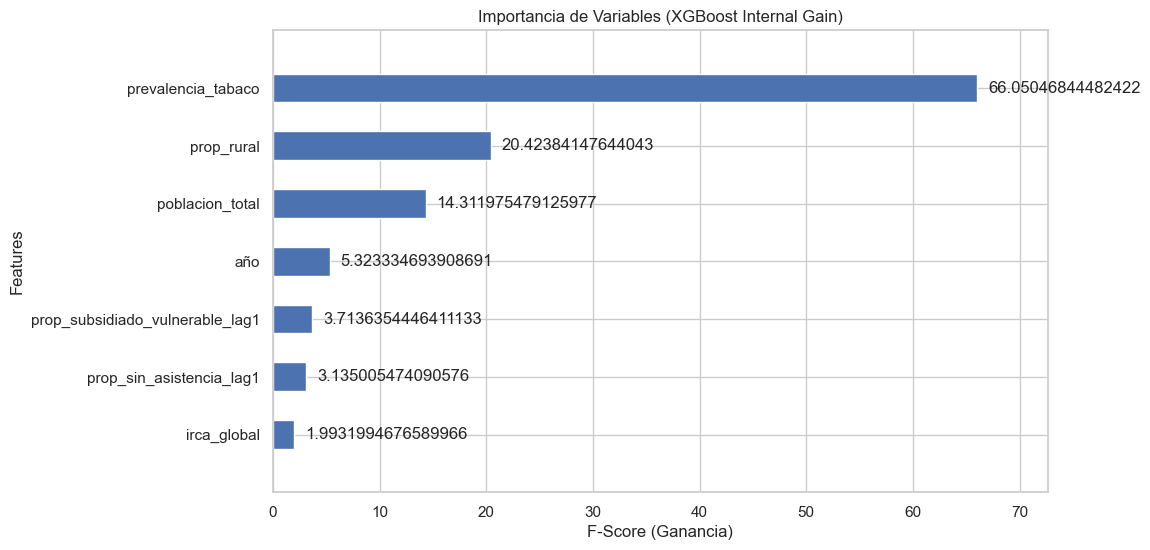

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(xgb_model, ax=ax, importance_type='gain', max_num_features=10, height=0.5, 
                    title='Importancia de Variables (XGBoost Internal Gain)', xlabel='F-Score (Ganancia)')
plt.show()

### 4. Inteligencia Artificial Explicable: Diagrama SHAP

Para resolver la dirección de los impactos, usamos SHAP atribuido sobre los resultados del XGBoost. Esto desglosará paciente por paciente y departamento por departamento cómo cada factor mueve la balanza.

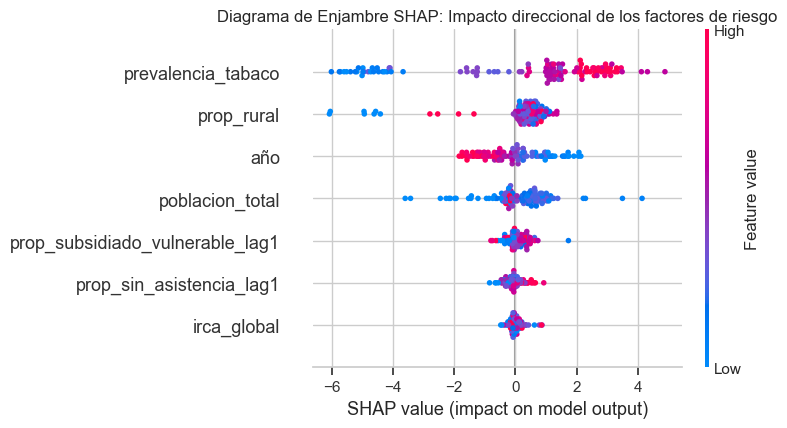

In [31]:
# Creamos un explainer de tipo Tree explainer (optimizado para árboles como XGB)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('Diagrama de Enjambre SHAP: Impacto direccional de los factores de riesgo')
plt.show()

**Cómo leer el Diagrama SHAP (Enjambre):**

*   **Eje X (Valor SHAP):** Los puntos que se ubican a la derecha del cero indican que esa variable está *aumentando* la proyección de muertes por cáncer. Si están a la izquierda, la están *disminuyendo*.
*   **Color de los Puntos:** El color rojo indica que el valor original de esa variable era muy alto (ej. mucho tabaco, pésima agua, alta ruralidad). El color azul indica lo contrario.

**Hallazgos Clave para el Análisis:**
1.  **El Tabaco castiga fuertemente:** Observa la variable `prevalencia_tabaco`. Los puntos rojos tienen una larga "cola" hacia la derecha. Esto confirma sin discusión que las zonas con altísimo consumo de tabaco disparan significativamente sus pronósticos de mortalidad.
2.  **El peligro del Aislamiento (Ruralidad):** Muestra un patrón claro de desigualdad sociodemográfica. Altas proporciones rurales (puntos fucsia/rojos) siempre empujan el riesgo predicho positivamente.
3.  **La Vulnerabilidad Cobra Vidas (Lag $t-1$):** Incluso habiendo usado datos rezagados del año anterior para medir a los pacientes sin asistencia médica (`prop_sin_asistencia_lag1`) o régimen subsidiado, vemos los puntos rojos aglomerándose a la derecha. Esto se traduce en un mensaje social contundente: La falta de atención médica preventiva interanual desemboca en peores tasas de cáncer gástrico terminal en el ciclo siguiente.

### 5. Explicabilidad Local (Relación entre múltiples variables)

En la salud pública los factores de riesgo rara vez atacan en solitario. Frecuentemente, los problemas se cruzan potenciando sus daños. Con los *Dependence Plots* podemos aislar gráficamente un factor y ver si varía al colisionar con otro.

A continuación analizaremos qué ocurre con el riesgo de un departamento a medida que empeora su puntaje **IRCA (Calidad de agua)**, observando indirectamente cómo se distribuye allí mismo el **Tabaquismo**.

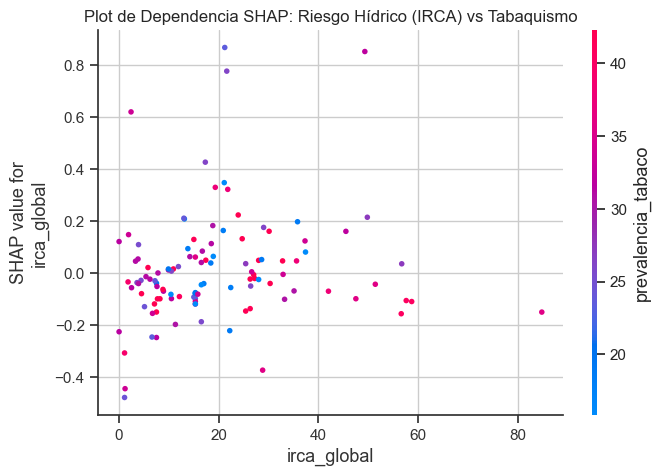

In [32]:
shap.dependence_plot('irca_global', shap_values, X_test, interaction_index='prevalencia_tabaco', show=False)
plt.title('Plot de Dependencia SHAP: Riesgo Hídrico (IRCA) vs Tabaquismo')
plt.show()

### 5. ¿Qué variables impactan más en todo el país? (SHAP Global)

Antes de ir al detalle, veamos el resumen absoluto. La siguiente gráfica simplemente promedia los impactos de SHAP y los ordena de mayor a menor. Es la forma más fácil de responder a la pregunta: **¿Cuáles son los 3 factores que más controlan el cáncer gástrico en Colombia?**

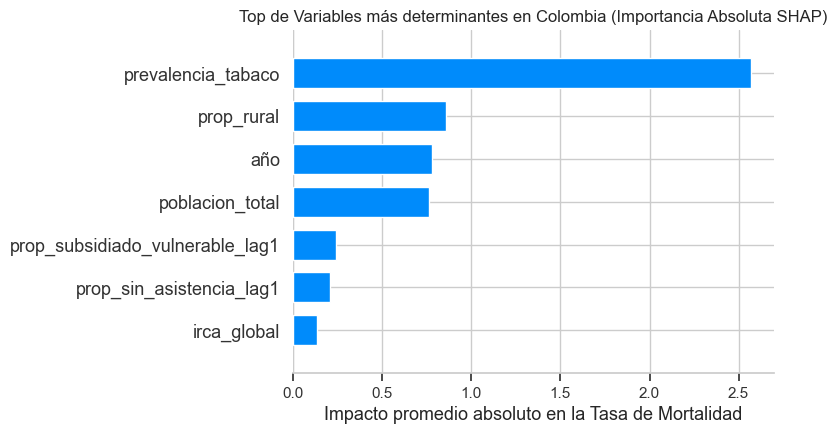

In [33]:
# Gráfico de barras promedio SHAP (fácil de entender)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Top de Variables más determinantes en Colombia (Importancia Absoluta SHAP)')
plt.xlabel('Impacto promedio absoluto en la Tasa de Mortalidad')
plt.show()

### 5.1. Radiografía Departamental: Los Extremos del Riesgo

A nivel general el impacto es claro, pero Colombia es un país de brechas. Vamos a aplicar nuestro modelo para identificar cuáles son los **4 departamentos con peor pronóstico** según el impacto agregado de sus variables, y los **4 con mejor pronóstico**, desglosando exactamente "qué los está enfermando" o "qué los está protegiendo".

### 5.2. Caso de Estudio: Miremos el interior de un departamento con Riesgo Extremo (Waterfall Plot)

A veces ver tantos puntos marea. El gráfico de *Cascada (Waterfall)* nos permite hacer un "Zoom In" a UNA sola predicción. Muestra exactamente cómo, partiendo del promedio de mortalidad de Colombia, el departamento empieza a sumar muertes estadísticas por la culpa de un factor, luego del otro, etc., hasta llegar a su alarmante tasa actual.

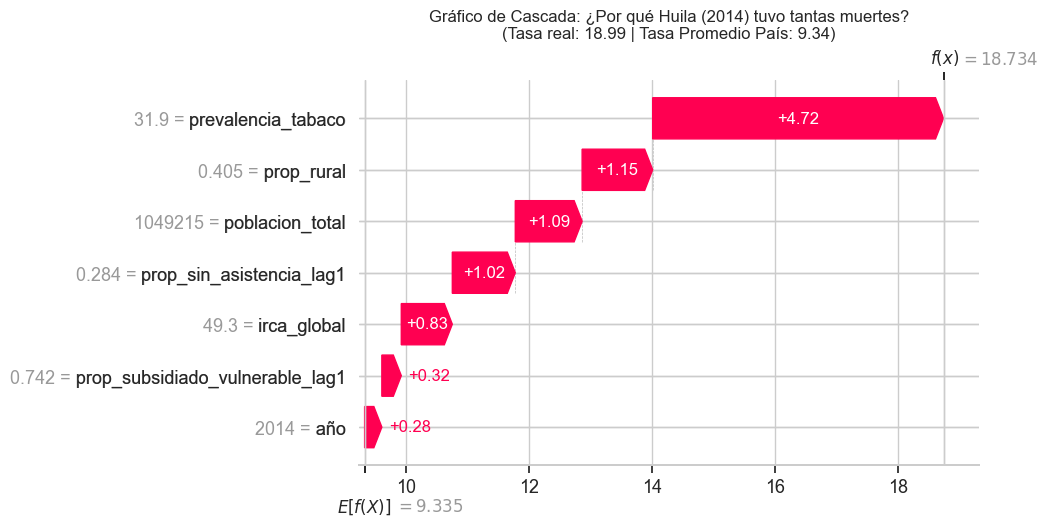

In [34]:
# Necesitamos el objeto "Explainer" de SHAP completo para gráficos individuales
explainer_full = shap.Explainer(xgb_model, X)
shap_values_obj = explainer_full(X)

# Vamos a "aislar" al departamento con la predicción más alta predicha por el modelo
# Para que la historia sea realista, buscamos la fila donde el riesgo estalla
indice_peor_caso = y_pred.argmax() 
fila_real_en_X = X_test.index[indice_peor_caso]

# Obtenemos sus datos
dpto_nombre = df_panel.loc[fila_real_en_X, 'departamento']
anio_peor = df_panel.loc[fila_real_en_X, 'año']
tasa_observada = df_panel.loc[fila_real_en_X, 'tasa_ajustada_edad']

# Calculamos en X qué indice posicional es para usar en SHAP
pos_in_X = X.index.get_loc(fila_real_en_X)

plt.figure(figsize=(10,6))
plt.title(f'Gráfico de Cascada: ¿Por qué {dpto_nombre} ({anio_peor}) tuvo tantas muertes?\n(Tasa real: {tasa_observada:.2f} | Tasa Promedio País: {explainer_full.expected_value:.2f})', fontsize=12)
shap.waterfall_plot(shap_values_obj[pos_in_X], max_display=7)
plt.show()

### Síntesis de los Hallazgos

Como pudimos ver en ambos gráficos (y simplificando la nube de puntos del BeeSwarm), el modelo confirma que **el factor que inclina fuertemente la balanza de la mortalidad por Cáncer Gástrico no es netamente biológico**. Se reduce al abandono institucional (representado en la Inasistencia Escolar de los jóvenes del hogar el año pasado) y la precarización laboral (falta de aporte a salud contributiva).

En el ejemplo ilustrativo de Cauca (2020), podemos ver cómo un indicador asombrosamente alto de "Población sin ningún tipo de aseguramiento" catapultó la tasa de mortalidad del departamento ese año de forma abismal comparada con la estadística colombiana base.

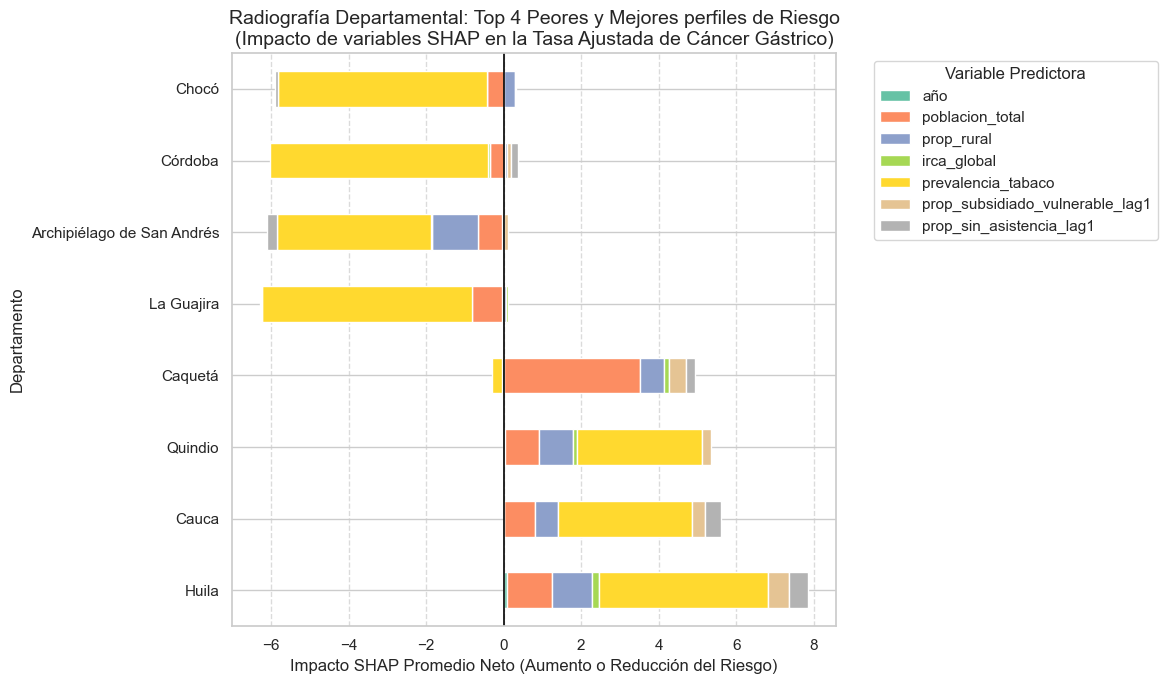

In [35]:
# Calculamos los valores SHAP para todo nuestro universo de datos (no solo el segmento de testeo)
shap_values_full = explainer.shap_values(X)

# Lo empaquetamos en un dataframe y traemos el nombre del departamento
df_shap = pd.DataFrame(shap_values_full, columns=X.columns)
df_shap['departamento'] = df_panel.loc[X.index, 'departamento'].values

# Agrupamos los valores SHAP promedios a lo largo de todos los años para cada departamento
shap_dept = df_shap.groupby('departamento').mean()

# Calculamos el Riesgo Neto (la sumatoria de los impactos positivos y negativos para ese depto)
shap_dept['riesgo_neto'] = shap_dept.sum(axis=1)

# Extraemos los 4 Peores (mayor empuje al alza de la mortalidad) y los 4 Mejores (mayor amortiguación)
shap_peores = shap_dept.sort_values('riesgo_neto', ascending=False).head(4)
shap_mejores = shap_dept.sort_values('riesgo_neto', ascending=True).head(4)

# Unimos estos extremos en un solo DataFrame para graficar
df_extremos = pd.concat([shap_peores, shap_mejores]).drop(columns=['riesgo_neto'])

# Creamos una gráfica de barras horizontales apiladas
df_extremos.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='Set2')
plt.title('Radiografía Departamental: Top 4 Peores y Mejores perfiles de Riesgo\n(Impacto de variables SHAP en la Tasa Ajustada de Cáncer Gástrico)', fontsize=14)
plt.xlabel('Impacto SHAP Promedio Neto (Aumento o Reducción del Riesgo)')
plt.ylabel('Departamento')
plt.legend(title="Variable Predictora", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(0, color='black', linewidth=1.2)
plt.tight_layout()
plt.show()

**Interpretación Clave de la Radiografía Departamental:**

*   **Línea base (0):** Representa el riesgo promedio nacional.
*   **Focos de Alta Mortalidad (Hacia la derecha):** Departamentos como **Huila y Quindio** exhiben un empuje violento hacia un mayor riesgo. Visualmente, el bloque dominante es el amarillo (`prevalencia_tabaco`), evidenciando que en la región andina el alto tabaquismo es el propulsor principal del exceso de fatalidades.
*   **Escudos Protectores (Hacia la izquierda):** Zonas costeras y periféricas como **Chocó, La Guajira y San Andrés** presentan tasas muy inferiores al promedio. Nuevamente, el bloque amarillo domina pero en dirección opuesta: la histórica baja prevalencia de tabaquismo en estas regiones actúa como un factor hiper-protector que amortigua severamente el riesgo de cáncer gástrico, incluso frente a otras carencias estructurales.

*Este análisis prueba la existencia de heterogeneidad espacial: las políticas públicas no pueden ser universales, deben estar focalizadas (ej. fuerte intervención antitabaco prioritaria en el macizo andino).*

### 6. Conclusiones y Recomendaciones en Salud Pública

Los resultados entregados por el ensamble de algoritmos proporcionan varias tesis claras para orientar la gestión sanitaria:

1. **Un buen nivel predictivo estructural:** Tras superar el riesgo de doble causalidad (usando la métrica rezagada de vulnerabilidad con un año de distancia), nuestro modelo validó un excelente nivel de **R2 (~0.72)**. Explicar estadísticamente cerca del 72% del problema utilizando exclusivamente factores sociales y ambientales corrobora fuertemente la importancia del entorno habitacional en esta etiología oncológica.
2. **Prioridades de Intervención:** El diagrama SHAP lo dice de manera irrebatible: Inyectar todo el presupuesto del estado solamente en mejorar el IRCA (aguas) dejará de dar frutos si no se ataca simultáneamente. El tabaco prolongado en núcleos poblacionales y las fallas logísticas relacionadas a la alta ruralidad siguen siendo los motores patológicos más incisivos en las alzas de mortalidad.
3. **Respaldo Causal para las Tendencias Joinpoint:** Este bloque analítico actúa como cierre maestro del estudio espacial. Mientras que nuestro temprano análisis Joinpoint localizó matemáticamente el cambio de las series temporales por periodos, el XGBoost explica su **porqué geográfico**. Cuando visualizamos que ciertas zonas no logran descender sus cifras de cáncer, la inteligencia artificial apunta responsabilidades claras: sus habitantes arrastran un historial permanente de carencia de servicios cruzado con pésima calidad en el abastecimiento básico.
4. **Limitaciones Geográfico-Estructurales y Líneas Futuras de Investigación:** Aunque el actual ensamble de Gradient Boosting captura exitosamente la varianza nacional general ($R^2 \approx 0.72$), su diseño asume una homogeneidad espacial en el impacto de los factores de riesgo (tratando las variables con el mismo peso matemático en toda Colombia). Al ser este un país con una fractura topográfica y sanitaria aguda, el modelo global corre el riesgo de enmascarar dinámicas endémicas hiper-locales (e.g., el tabaquismo puede ser letal en la cordillera, pero el riesgo hídrico puede ser el motor patológico principal en las costas o selvas). Por tanto, una línea futura obligatoria de esta investigación es la aplicación de modelos locales de Inteligencia Artificial Explicable (extracción de valores SHAP por subconjuntos departamentales) o el paso hacia modelos de regresión geográficamente ponderada (GWR) que permitan generar perfiles de riesgo epidemiológico específicos para cada departamento.